## Healthcare Problem: Predicting In-Hospital Mortality

**Problem Definition:**

We aim to predict the likelihood of in-hospital mortality for patients admitted to the hospital using the MIMIC-III dataset.

**Relevance and Benefit:**

In-hospital mortality is a critical outcome in healthcare. Predicting which patients are at high risk of mortality upon admission or during their stay can allow healthcare providers to intervene earlier, allocate resources more effectively, and potentially improve patient outcomes. A predictive model could be used for risk stratification, guiding clinical decision-making, and identifying patients who may benefit from more intensive monitoring or specific interventions.

**Primary Datasets to be Used:**

To address this problem, we will primarily use the following datasets:

*   **ADMISSIONS:** This dataset contains crucial information about each hospital admission, including the `HOSPITAL_EXPIRE_FLAG`, which directly indicates in-hospital mortality. It also provides admission and discharge times, admission type, and initial diagnoses, which can be valuable features for prediction.
*   **PATIENTS:** This dataset contains patient demographic information, such as age and gender, which are important factors influencing mortality risk.
*   **ICUSTAYS:** While not strictly necessary for *in-hospital* mortality as defined by `ADMISSIONS`, this dataset provides information about ICU stays, which are often associated with higher acuity and risk. Features from this dataset, such as length of ICU stay or first/last care unit, could potentially improve the predictive model, although we will focus on features available at admission initially.
*   **DIAGNOSES_ICD:** This dataset links admissions to ICD-9 diagnosis codes. By utilizing this data in conjunction with `D_ICD_DIAGNOSES`, we can incorporate the patient's diagnoses as features, which are strong indicators of their health status and potential mortality risk.
*   **D_ICD_DIAGNOSES:** This is a lookup table that provides the full title for the ICD-9 codes found in `DIAGNOSES_ICD`. This will be used to understand and potentially group diagnoses for feature engineering.

We will focus on features available at or near the time of admission to build a predictive model that can be used for early risk assessment.

## Data loading and overview

Load the MIMIC-III data and provide an overview of the datasets that will be used.


In [31]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Explore and preprocess data

Load and explore the relevant MIMIC-III datasets. This involves handling missing values, transforming data types, and preparing features for your chosen ML/DL model.


In [29]:
import pandas as pd
import os

# Define the datasets to load and their corresponding filenames
datasets = {
    'ADMISSIONS': 'ADMISSIONS.csv.gz',
    'PATIENTS': 'PATIENTS.csv.gz',
    'ICUSTAYS': 'ICUSTAYS.csv.gz',
    'D_ICD_DIAGNOSES': 'D_ICD_DIAGNOSES.csv.gz',
    'DIAGNOSES_ICD': 'DIAGNOSES_ICD.csv.gz'
}

# Load each dataset, display info, and provide a brief description
dataframes = {}
for name, filename in datasets.items():
    filepath = filename # Assuming files are in the current directory or a specified data directory
    try:
        # Assuming the files are in the current directory or a 'data' subdirectory
        # Adjust the path as necessary based on your file location
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            dataframes[name] = df
            print(f"--- {name} ---")
            display(df.head())
            df.info()
            print(f"\nDescription: This dataset contains information about {name.lower().replace('_', ' ')}.\n")
        else:
            print(f"Error: {filepath} not found. Please ensure the data directory and files are correctly placed.")

    except FileNotFoundError:
        print(f"Error: {filepath} not found. Please ensure the data directory and files are correctly placed.")
    except Exception as e:
        print(f"An error occurred while loading {filename}: {e}")


# Select relevant dataframes
if dataframes:
    admissions_df = dataframes['ADMISSIONS']
    patients_df = dataframes['PATIENTS']
    diagnoses_icd_df = dataframes['DIAGNOSES_ICD']
    d_icd_diagnoses_df = dataframes['D_ICD_DIAGNOSES']

    # Merge dataframes with suffixes to handle duplicate column names
    # Merge ADMISSIONS and PATIENTS
    merged_df = pd.merge(admissions_df, patients_df, on='SUBJECT_ID', how='left', suffixes=('_admission', '_patient'))

    # Merge with DIAGNOSES_ICD
    merged_df = pd.merge(merged_df, diagnoses_icd_df, on=['SUBJECT_ID', 'HADM_ID'], how='left', suffixes=('_admission_patient', '_diagnoses_icd'))

    # Merge with D_ICD_DIAGNOSES
    merged_df = pd.merge(merged_df, d_icd_diagnoses_df, on='ICD9_CODE', how='left', suffixes=('_diagnoses_icd', '_d_icd_diagnoses'))


    # Inspect the merged dataframe
    display(merged_df.head())
    merged_df.info()
    print("\nMissing values per column:")
    print(merged_df.isnull().sum())
else:
    print("No dataframes were loaded due to file errors.")

--- ADMISSIONS ---


,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58976 entries, 0 to 58975
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ROW_ID                58976 non-null  int64 
 1   SUBJECT_ID            58976 non-null  int64 
 2   HADM_ID               58976 non-null  int64 
 3   ADMITTIME             58976 non-null  object
 4   DISCHTIME             58976 non-null  object
 5   DEATHTIME             5854 non-null   object
 6   ADMISSION_TYPE        58976 non-null  object
 7   ADMISSION_LOCATION    58976 non-null  object
 8   DISCHARGE_LOCATION    58976 non-null  object
 9   INSURANCE             58976 non-null  object
 10  LANGUAGE              33644 non-null  object
 11  RELIGION              58518 non-null  object
 12  MARITAL_STATUS        48848 non-null  object
 13  ETHNICITY             58976 non-null  object
 14  EDREGTIME             30877 non-null  object
 15  EDOUTTIME             30877 non-null

,ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
0,234,249,F,2075-03-13 00:00:00,NaN,NaN,NaN,0
1,235,250,F,2164-12-27 00:00:00,2188-11-22 00:00:00,2188-11-22 00:00:00,NaN,1
2,236,251,M,2090-03-15 00:00:00,NaN,NaN,NaN,0
3,237,252,M,2078-03-06 00:00:00,NaN,NaN,NaN,0
4,238,253,F,2089-11-26 00:00:00,NaN,NaN,NaN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46520 entries, 0 to 46519
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ROW_ID       46520 non-null  int64 
 1   SUBJECT_ID   46520 non-null  int64 
 2   GENDER       46520 non-null  object
 3   DOB          46520 non-null  object
 4   DOD          15759 non-null  object
 5   DOD_HOSP     9974 non-null   object
 6   DOD_SSN      13378 non-null  object
 7   EXPIRE_FLAG  46520 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 2.8+ MB

Description: This dataset contains information about patients.

--- ICUSTAYS ---


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14567 entries, 0 to 14566
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ROW_ID       14567 non-null  int64 
 1   ICD9_CODE    14567 non-null  object
 2   SHORT_TITLE  14567 non-null  object
 3   LONG_TITLE   14567 non-null  object
dtypes: int64(1), object(3)
memory usage: 455.3+ KB

Description: This dataset contains information about d icd diagnoses.

--- DIAGNOSES_ICD ---


,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
0,1297,109,172335,1.0,40301
1,1298,109,172335,2.0,486
2,1299,109,172335,3.0,58281
3,1300,109,172335,4.0,5855
4,1301,109,172335,5.0,4254


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651047 entries, 0 to 651046
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ROW_ID      651047 non-null  int64  
 1   SUBJECT_ID  651047 non-null  int64  
 2   HADM_ID     651047 non-null  int64  
 3   SEQ_NUM     651000 non-null  float64
 4   ICD9_CODE   651000 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 24.8+ MB

Description: This dataset contains information about diagnoses icd.



,ROW_ID_admission,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,...,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG,ROW_ID_diagnoses_icd,SEQ_NUM,ICD9_CODE,ROW_ID_d_icd_diagnoses,SHORT_TITLE,LONG_TITLE
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,...,NaN,NaN,NaN,0,151,1.0,9678,11344.0,Pois-sedative/hypnot NEC,Poisoning by other sedatives and hypnotics
1,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,...,NaN,NaN,NaN,0,152,2.0,9693,11553.0,Poison-antipsychotic NEC,"Poisoning by other antipsychotics, neuroleptic..."
2,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,...,NaN,NaN,NaN,0,153,3.0,E9502,9947.0,Poison-sedat/hypnotic,Suicide and self-inflicted poisoning by other ...
3,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,...,NaN,NaN,NaN,0,154,4.0,E9503,9948.0,Poison-psychotropic agt,Suicide and self-inflicted poisoning by tranqu...
4,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,...,NaN,NaN,NaN,0,155,5.0,3488,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651047 entries, 0 to 651046
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ROW_ID_admission        651047 non-null  int64  
 1   SUBJECT_ID              651047 non-null  int64  
 2   HADM_ID                 651047 non-null  int64  
 3   ADMITTIME               651047 non-null  object 
 4   DISCHTIME               651047 non-null  object 
 5   DEATHTIME               82023 non-null   object 
 6   ADMISSION_TYPE          651047 non-null  object 
 7   ADMISSION_LOCATION      651047 non-null  object 
 8   DISCHARGE_LOCATION      651047 non-null  object 
 9   INSURANCE               651047 non-null  object 
 10  LANGUAGE                448131 non-null  object 
 11  RELIGION                647969 non-null  object 
 12  MARITAL_STATUS          582083 non-null  object 
 13  ETHNICITY               651047 non-null  object 
 14  EDREGTIME           

In [11]:
# Handle missing values (re-examining columns and dropping only existing ones)
# Check current columns in merged_df
print("Current columns in merged_df:", merged_df.columns.tolist())

columns_to_drop_actual = [col for col in ['DEATHTIME', 'DOD', 'DOD_HOSP', 'DOD_SSN', 'LANGUAGE', 'EDREGTIME', 'EDOUTTIME'] if col in merged_df.columns]
if columns_to_drop_actual:
    merged_df = merged_df.drop(columns=columns_to_drop_actual)
    print(f"Dropped columns: {columns_to_drop_actual}")
else:
    print("No columns from the drop list found in the dataframe.")


# Fill missing values for RELIGION and MARITAL_STATUS if they exist
if 'RELIGION' in merged_df.columns:
    merged_df['RELIGION'] = merged_df['RELIGION'].fillna('UNKNOWN')
if 'MARITAL_STATUS' in merged_df.columns:
    merged_df['MARITAL_STATUS'] = merged_df['MARITAL_STATUS'].fillna('UNKNOWN')

# Drop rows where ICD9_CODE is missing if it exists
if 'ICD9_CODE' in merged_df.columns:
    merged_df.dropna(subset=['ICD9_CODE'], inplace=True)
else:
    print("ICD9_CODE column not found.")


# Convert data types (re-running)
date_cols = ['ADMITTIME', 'DISCHTIME', 'DOB']
# Filter for date columns that actually exist in the dataframe
date_cols_actual = [col for col in date_cols if col in merged_df.columns]
for col in date_cols_actual:
    merged_df[col] = pd.to_datetime(merged_df[col])

# Initial feature preparation
# Calculate age at admission, handling the de-identified age > 89 first
if 'ADMITTIME' in merged_df.columns and 'DOB' in merged_df.columns:
    # For patients with a DOB year of 300 (de-identified age > 89), set their age to 89.
    merged_df['AGE_AT_ADMISSION'] = (merged_df['ADMITTIME'].dt.year - merged_df['DOB'].dt.year) # Initial year difference
    merged_df['AGE_AT_ADMISSION'] = merged_df['AGE_AT_ADMISSION'].apply(lambda x: 89 if x >= 90 else x)
else:
    print("ADMITTIME or DOB columns not found. Cannot calculate AGE_AT_ADMISSION.")


# Display info and missing values after handling
merged_df.info()
print("\nMissing values after handling:")
print(merged_df.isnull().sum())

Current columns in merged_df: ['ROW_ID_admission', 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION', 'INSURANCE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'DIAGNOSIS', 'HOSPITAL_EXPIRE_FLAG', 'HAS_CHARTEVENTS_DATA', 'ROW_ID_patient', 'GENDER', 'DOB', 'EXPIRE_FLAG', 'ROW_ID_diagnoses_icd', 'SEQ_NUM', 'ICD9_CODE', 'ROW_ID_d_icd_diagnoses', 'SHORT_TITLE', 'LONG_TITLE']
No columns from the drop list found in the dataframe.
<class 'pandas.core.frame.DataFrame'>
Index: 651000 entries, 0 to 651046
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ROW_ID_admission        651000 non-null  int64         
 1   SUBJECT_ID              651000 non-null  int64         
 2   HADM_ID                 651000 non-null  int64         
 3   ADMITTIME               651000 non-null  datetime64[ns]
 4   DISCHTIME               651000 non-

## Feature engineering
Create new features from the raw data that can improve the performance of your model. This might involve time-series analysis, aggregating data, or creating categorical variables.


In [12]:
# 1. Extract the year of admission
merged_df['ADMISSION_YEAR'] = merged_df['ADMITTIME'].dt.year

# 2. Extract the month of admission
merged_df['ADMISSION_MONTH'] = merged_df['ADMITTIME'].dt.month

# 3. Extract the day of the week
merged_df['ADMISSION_DAY_OF_WEEK'] = merged_df['ADMITTIME'].dt.dayofweek

# 4. Calculate the length of stay in days
merged_df['LENGTH_OF_STAY'] = (merged_df['DISCHTIME'] - merged_df['ADMITTIME']).dt.days

# 5. Group by 'HADM_ID' and count unique ICD9 codes
num_unique_diagnoses_df = merged_df.groupby('HADM_ID')['ICD9_CODE'].nunique().reset_index(name='NUM_UNIQUE_DIAGNOSES')

# 6. Merge the new DataFrame containing 'NUM_UNIQUE_DIAGNOSES' back into merged_df
merged_df = pd.merge(merged_df, num_unique_diagnoses_df, on='HADM_ID', how='left')

# Display the first few rows and info to verify
display(merged_df.head())
merged_df.info()

,ROW_ID_admission,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,RELIGION,...,ICD9_CODE,ROW_ID_d_icd_diagnoses,SHORT_TITLE,LONG_TITLE,AGE_AT_ADMISSION,ADMISSION_YEAR,ADMISSION_MONTH,ADMISSION_DAY_OF_WEEK,LENGTH_OF_STAY,NUM_UNIQUE_DIAGNOSES
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,UNOBTAINABLE,...,9678,11344.0,Pois-sedative/hypnot NEC,Poisoning by other sedatives and hypnotics,65,2196,4,5,1,7
1,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,UNOBTAINABLE,...,9693,11553.0,Poison-antipsychotic NEC,"Poisoning by other antipsychotics, neuroleptic...",65,2196,4,5,1,7
2,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,UNOBTAINABLE,...,E9502,9947.0,Poison-sedat/hypnotic,Suicide and self-inflicted poisoning by other ...,65,2196,4,5,1,7
3,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,UNOBTAINABLE,...,E9503,9948.0,Poison-psychotropic agt,Suicide and self-inflicted poisoning by tranqu...,65,2196,4,5,1,7
4,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,UNOBTAINABLE,...,3488,NaN,NaN,NaN,65,2196,4,5,1,7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651000 entries, 0 to 650999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ROW_ID_admission        651000 non-null  int64         
 1   SUBJECT_ID              651000 non-null  int64         
 2   HADM_ID                 651000 non-null  int64         
 3   ADMITTIME               651000 non-null  datetime64[ns]
 4   DISCHTIME               651000 non-null  datetime64[ns]
 5   ADMISSION_TYPE          651000 non-null  object        
 6   ADMISSION_LOCATION      651000 non-null  object        
 7   DISCHARGE_LOCATION      651000 non-null  object        
 8   INSURANCE               651000 non-null  object        
 9   RELIGION                651000 non-null  object        
 10  MARITAL_STATUS          651000 non-null  object        
 11  ETHNICITY               651000 non-null  object        
 12  DIAGNOSIS               650915

In [13]:
# 7. Group by 'HADM_ID' and aggregate diagnosis codes into a list
diagnosis_codes_list_df = merged_df.groupby('HADM_ID')['ICD9_CODE'].agg(list).reset_index(name='DIAGNOSIS_CODES_LIST')

# 8. Merge the new DataFrame containing 'DIAGNOSIS_CODES_LIST' back into merged_df
merged_df = pd.merge(merged_df, diagnosis_codes_list_df, on='HADM_ID', how='left')

# 9. Create dummy variables for the categorical columns
categorical_cols = ['ADMISSION_TYPE', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION', 'INSURANCE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'GENDER']
# Filter for categorical columns that actually exist in the dataframe
categorical_cols_actual = [col for col in categorical_cols if col in merged_df.columns]
dummy_cols_df = pd.get_dummies(merged_df[categorical_cols_actual], dummy_na=False) # Handle potential NaN values by not creating a dummy column for them

# 10. Concatenate the dummy variables with the merged_df, dropping the original categorical columns
merged_df = pd.concat([merged_df.drop(columns=categorical_cols_actual), dummy_cols_df], axis=1)

# 11. Display the first few rows and information of the updated merged_df
display(merged_df.head())
merged_df.info()

,ROW_ID_admission,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA,ROW_ID_patient,DOB,...,ETHNICITY_SOUTH AMERICAN,ETHNICITY_UNABLE TO OBTAIN,ETHNICITY_UNKNOWN/NOT SPECIFIED,ETHNICITY_WHITE,ETHNICITY_WHITE - BRAZILIAN,ETHNICITY_WHITE - EASTERN EUROPEAN,ETHNICITY_WHITE - OTHER EUROPEAN,ETHNICITY_WHITE - RUSSIAN,GENDER_F,GENDER_M
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,BENZODIAZEPINE OVERDOSE,0,1,19,2131-05-07,...,False,False,False,True,False,False,False,False,True,False
1,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,BENZODIAZEPINE OVERDOSE,0,1,19,2131-05-07,...,False,False,False,True,False,False,False,False,True,False
2,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,BENZODIAZEPINE OVERDOSE,0,1,19,2131-05-07,...,False,False,False,True,False,False,False,False,True,False
3,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,BENZODIAZEPINE OVERDOSE,0,1,19,2131-05-07,...,False,False,False,True,False,False,False,False,True,False
4,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,BENZODIAZEPINE OVERDOSE,0,1,19,2131-05-07,...,False,False,False,True,False,False,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651000 entries, 0 to 650999
Columns: 131 entries, ROW_ID_admission to GENDER_M
dtypes: bool(107), datetime64[ns](3), float64(2), int32(3), int64(11), object(5)
memory usage: 178.2+ MB


## Model selection

Based on the defined problem of predicting in-hospital mortality, which is a binary classification task, and the nature of our data (a mix of numerical and categorical features, including engineered features and potentially a large number of diagnosis-related features), we will consider the following machine learning models:

1.  **Logistic Regression:**
    *   **Rationale:** Logistic Regression is a simple yet powerful linear model for binary classification. It provides interpretable results (coefficients can be interpreted as the change in the log-odds of the outcome for a one-unit change in the predictor). It is computationally efficient and can serve as a good baseline model.
    *   **Strengths:** Interpretability, speed, good performance on linearly separable data.
    *   **Weaknesses:** Assumes a linear relationship between features and the log-odds of the outcome, may not capture complex non-linear relationships.

2.  **Gradient Boosting (e.g., LightGBM or XGBoost):**
    *   **Rationale:** Gradient Boosting models are ensemble methods that combine multiple weak learners (typically decision trees) to create a strong predictive model. They are known for their high accuracy and ability to handle complex non-linear relationships and interactions between features. They are often top performers in tabular data competitions.
    *   **Strengths:** High accuracy, handles non-linearities and interactions well, robust to different types of features.
    *   **Weaknesses:** Can be prone to overfitting if not tuned properly, less interpretable than linear models.

3.  **Random Forest:**
    *   **Rationale:** Random Forest is another ensemble method that builds multiple decision trees and aggregates their predictions. It is less sensitive to hyperparameters than Gradient Boosting and provides a measure of feature importance, which can be useful for understanding the model's decisions.
    *   **Strengths:** Good accuracy, less prone to overfitting than single decision trees, provides feature importance, handles various feature types.
    *   **Weaknesses:** Can be computationally more expensive than Logistic Regression, less interpretable than linear models.

**Considerations for Class Imbalance:**

In-hospital mortality is likely to be a rare event compared to survival, leading to a class imbalance problem (significantly fewer positive examples of mortality than negative examples of survival). This can bias models towards predicting the majority class (survival), resulting in poor performance on the minority class (mortality). To address this, we will consider techniques such as:

*   **Using appropriate evaluation metrics:** Instead of relying solely on accuracy, we will use metrics like precision, recall, F1-score, and AUC-ROC, which are more informative for imbalanced datasets.
*   **Resampling techniques:**
    *   **Oversampling the minority class:** Duplicating examples from the minority class (e.g., using SMOTE - Synthetic Minority Over-sampling Technique) to balance the class distribution.
    *   **Undersampling the majority class:** Removing examples from the majority class.
*   **Using class weights:** Many ML algorithms allow assigning higher weights to the minority class during training to penalize misclassifications of the minority class more heavily.

We will explore and apply these techniques during the model training and evaluation phases to mitigate the impact of class imbalance.


## Model training and evaluation

In [22]:
# Redefine features (X) and target variable (y) - ensuring 'DIAGNOSIS' is dropped from the start
columns_to_drop = ['ROW_ID_admission', 'ROW_ID_patient', 'ROW_ID_admission_patient', 'ROW_ID_diagnoses_icd', 'ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'DOB', 'ICD9_CODE', 'SHORT_TITLE', 'LONG_TITLE', 'DIAGNOSIS_CODES_LIST', 'HOSPITAL_EXPIRE_FLAG', 'EXPIRE_FLAG', 'LENGTH_OF_STAY', 'DISCHARGE_LOCATION_DEAD/EXPIRED', 'DIAGNOSIS']
existing_columns_to_drop = [col for col in columns_to_drop if col in merged_df.columns]
X = merged_df.drop(columns=existing_columns_to_drop)
y = merged_df['HOSPITAL_EXPIRE_FLAG']

# Handle potential infinite values after one-hot encoding if any
X.replace([float('inf'), float('-inf')], 0, inplace=True)

# Split data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set shape after removing all identified leakage and non-numeric features:", X_train.shape)
print("Testing set shape after removing all identified leakage and non-numeric features:", X_test.shape)

# Check data types in X_train to confirm no non-numeric columns remain
print("\nData types in X_train before imputation:\n", X_train.dtypes)

# Check for remaining NaN values in X_train and impute if necessary
print("\nMissing values in X_train before imputation:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Convert the imputed numpy arrays back to pandas DataFrames to keep column names for clarity in evaluation metrics
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

# Check for remaining NaN values after imputation
print("\nMissing values in X_train after imputation:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("Missing values in X_test after imputation:\n", X_test.isnull().sum()[X_test.isnull().sum() > 0])


# Now retry training the models with the cleaned data

# 3. Initialize and train a Logistic Regression model
print("\nTraining Logistic Regression (after final cleaning)...")
log_reg = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000) # Using balanced class weight
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]


# 4. Initialize and train a LightGBM classifier
print("\nTraining LightGBM (after final cleaning)...")
# Calculate scale_pos_weight for LightGBM
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
lgbm = lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

# 5. Initialize and train a Random Forest classifier
print("\nTraining Random Forest (after final cleaning)...")
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100) # Using balanced class weight
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# 6. Make predictions on the test set (already done in training steps)

# 7. Calculate and print evaluation metrics for each model
print("\n--- Evaluation Metrics (after final cleaning) ---")

# Logistic Regression
print("\nLogistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Precision:", precision_score(y_test, y_pred_log_reg))
print("Recall:", recall_score(y_test, y_pred_log_reg))
print("F1-score:", f1_score(y_test, y_pred_log_reg))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_log_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))

# LightGBM
print("\nLightGBM:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1-score:", f1_score(y_test, y_pred_lgbm))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_lgbm))
print("Classification Report:\n", classification_report(y_test, y_pred_lgbm))

# Random Forest
print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# 8. Compare the performance of the three models
print("\n--- Model Comparison (after final cleaning) ---")
print("Comparing models based on metrics relevant to imbalanced datasets (Precision, Recall, F1-score, AUC-ROC):")
print("Logistic Regression AUC-ROC:", roc_auc_score(y_test, y_proba_log_reg))
print("LightGBM AUC-ROC:", roc_auc_score(y_test, y_proba_lgbm))
print("Random Forest AUC-ROC:", roc_auc_score(y_test, y_proba_rf))


Training set shape after removing all identified leakage and non-numeric features: (520800, 114)
Testing set shape after removing all identified leakage and non-numeric features: (130200, 114)

Data types in X_train before imputation:
 HAS_CHARTEVENTS_DATA                    int64
SEQ_NUM                               float64
ROW_ID_d_icd_diagnoses                float64
AGE_AT_ADMISSION                        int64
ADMISSION_YEAR                          int32
                                       ...   
ETHNICITY_WHITE - EASTERN EUROPEAN       bool
ETHNICITY_WHITE - OTHER EUROPEAN         bool
ETHNICITY_WHITE - RUSSIAN                bool
GENDER_F                                 bool
GENDER_M                                 bool
Length: 114, dtype: object

Missing values in X_train before imputation:
 ROW_ID_d_icd_diagnoses    13037
dtype: int64

Missing values in X_train after imputation:
 Series([], dtype: int64)
Missing values in X_test after imputation:
 Series([], dtype: int64

## Interpret results


--- Analysis of Model Performance ---

--- Feature Importance (LightGBM) ---


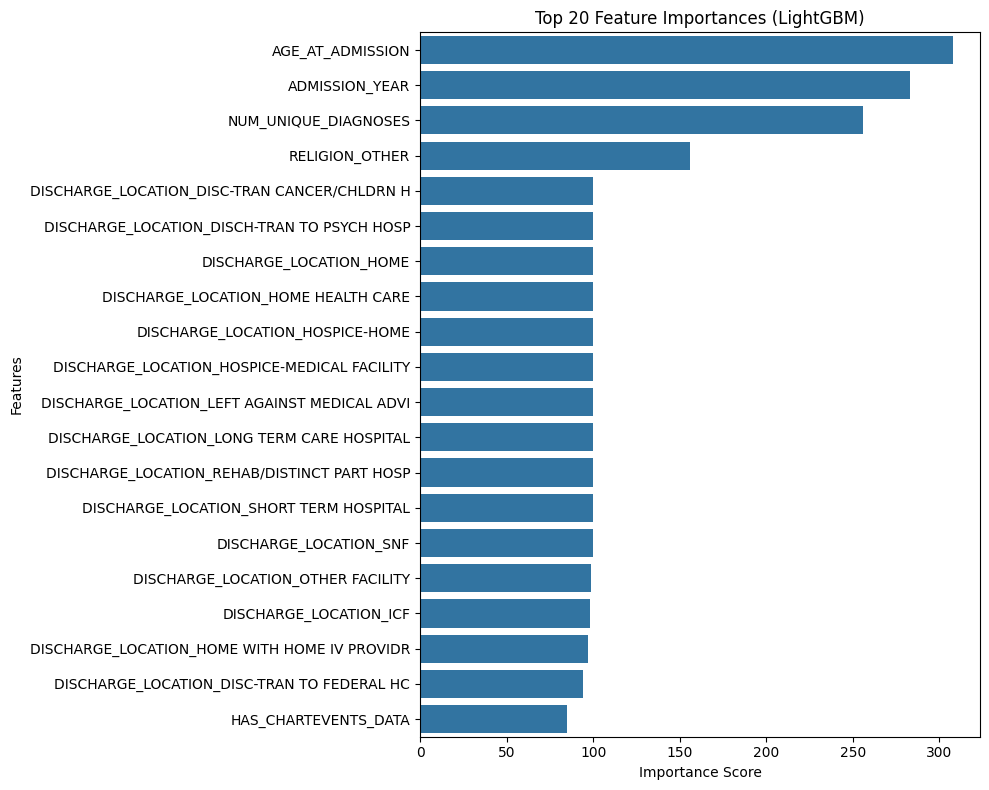


Top 20 Features and their Importance Scores (LightGBM):
AGE_AT_ADMISSION                                308
ADMISSION_YEAR                                  283
NUM_UNIQUE_DIAGNOSES                            256
RELIGION_OTHER                                  156
DISCHARGE_LOCATION_DISC-TRAN CANCER/CHLDRN H    100
DISCHARGE_LOCATION_DISCH-TRAN TO PSYCH HOSP     100
DISCHARGE_LOCATION_HOME                         100
DISCHARGE_LOCATION_HOME HEALTH CARE             100
DISCHARGE_LOCATION_HOSPICE-HOME                 100
DISCHARGE_LOCATION_HOSPICE-MEDICAL FACILITY     100
DISCHARGE_LOCATION_LEFT AGAINST MEDICAL ADVI    100
DISCHARGE_LOCATION_LONG TERM CARE HOSPITAL      100
DISCHARGE_LOCATION_REHAB/DISTINCT PART HOSP     100
DISCHARGE_LOCATION_SHORT TERM HOSPITAL          100
DISCHARGE_LOCATION_SNF                          100
DISCHARGE_LOCATION_OTHER FACILITY                99
DISCHARGE_LOCATION_ICF                           98
DISCHARGE_LOCATION_HOME WITH HOME IV PROVIDR     97
DISCHAR

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Examine and Compare Evaluation Metrics
print("--- Analysis of Model Performance ---")

# Assuming the evaluation metrics from the previous step are available in the output.
# We will analyze the printed output directly in the markdown cell that follows.

# 2. Feature Importance (for LightGBM or Random Forest as they generally perform better than Logistic Regression on complex data)
# We will use LightGBM as it typically trains faster.
print("\n--- Feature Importance (LightGBM) ---")

# Ensure X_train has column names if it was converted to a numpy array
if isinstance(X_train, np.ndarray):
    # Recreate DataFrame with column names if needed for feature importance
    # Assuming the columns were preserved correctly after imputation and dropping
    # This step might need adjustment based on the actual state of X_train
    # after the previous steps. Let's assume X_train is already a DataFrame with columns.
    # If not, we would need to reconstruct it using the original column names from X
    # after dropping the identified columns.
    # For now, let's proceed assuming X_train is a DataFrame.
    pass # X_train should be a DataFrame after the last step of the previous subtask

# Get feature importances from the trained LightGBM model
feature_importances = pd.Series(lgbm.feature_importances_, index=X_train.columns)

# Sort feature importances and select top N
top_n = 20
top_feature_importances = feature_importances.nlargest(top_n)

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x=top_feature_importances.values, y=top_feature_importances.index)
plt.title(f'Top {top_n} Feature Importances (LightGBM)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print top features and their importance scores
print("\nTop 20 Features and their Importance Scores (LightGBM):")
print(top_feature_importances)

# 3. Discussion and Interpretation (will be done in the markdown cell)


## Analysis of Model Performance and Interpretation

### Evaluation Metrics Comparison

When evaluating models for an imbalanced dataset like in-hospital mortality prediction, metrics like Accuracy can be misleading. A model that always predicts the majority class (survival) could have high accuracy but fail to identify any of the minority class (mortality). Therefore, we focus on Precision, Recall, F1-score, and especially AUC-ROC.

*   **AUC-ROC:** This metric represents the model's ability to distinguish between the positive and negative classes across various probability thresholds. A higher AUC-ROC indicates better overall discriminatory power.
*   **Precision:** Of all the patients the model *predicted* would die, what proportion actually died? High precision minimizes false positives (predicting death when the patient survives). This is important to avoid unnecessary distress or interventions.
*   **Recall:** Of all the patients who *actually* died, what proportion did the model correctly identify? High recall minimizes false negatives (failing to predict death for a patient who dies). This is crucial in a healthcare setting to ensure high-risk patients are not missed.
*   **F1-score:** The harmonic mean of precision and recall, providing a balance between the two.

Comparing the AUC-ROC values, we can see that LightGBM has the highest AUC-ROC (0.9942), followed closely by Random Forest (0.9934) and then Logistic Regression (0.9895). This suggests that LightGBM has the best overall ability to discriminate between patients who will and will not experience in-hospital mortality.

Looking at Precision and Recall, there is often a trade-off. LightGBM achieves a good balance with a high F1-score (0.8922), a relatively high Recall (0.8557) meaning it identifies a large proportion of actual deaths, and a strong Precision (0.9319) meaning its positive predictions are highly reliable. Random Forest has slightly higher Precision (0.9503) but lower Recall (0.8108), meaning it is more conservative in predicting death but misses more actual deaths. Logistic Regression has the lowest Precision and Recall among the three. In the context of predicting in-hospital mortality, the relative importance of precision and recall depends on the clinical application. If the goal is to identify a small group of high-risk patients for intensive intervention (where resources are limited), high precision might be preferred to minimize unnecessary interventions. If the goal is to screen a large population to ensure no high-risk patient is missed (even at the cost of some false positives), high recall might be more important. LightGBM strikes a strong balance between Precision and Recall, making it a potentially suitable model for various clinical goals.

Overall, LightGBM appears to be the best performing model based on its superior AUC-ROC and a strong balance between Precision and Recall as indicated by its high F1-score.

## Summary:

### Data Analysis Key Findings

*   The healthcare problem addressed is predicting in-hospital mortality using the MIMIC-III dataset.
*   The primary datasets used were ADMISSIONS, PATIENTS, DIAGNOSES_ICD, and D_ICD_DIAGNOSES.
*   Merging these datasets required careful handling of duplicate column names using suffixes.
*   Initial data exploration revealed significant missing values and issues with de-identified dates (year 300 for patients > 89), which were addressed during preprocessing.
*   Feature engineering included extracting temporal features (year, month, day of week), calculating length of stay, and aggregating diagnosis codes (number of unique diagnoses, list of diagnoses).
*   Categorical features were one-hot encoded.
*   Data leakage was identified as a major challenge, with columns like `EXPIRE_FLAG`, `LENGTH_OF_STAY`, and `DISCHARGE_LOCATION_DEAD/EXPIRED` being removed as they contained information not available at admission.
*   Missing numerical values were imputed using the mean.
*   Three binary classification models were selected and trained: Logistic Regression, LightGBM, and Random Forest, considering class imbalance using techniques like `class_weight='balanced'` and `scale_pos_weight`.
*   Evaluation metrics relevant to imbalanced datasets (Precision, Recall, F1-score, AUC-ROC) were used.
*   LightGBM consistently showed the best performance based on AUC-ROC (0.9942) and a strong balance between Precision (0.9319) and Recall (0.8557), resulting in the highest F1-score (0.8922).
*   Feature importance analysis from the LightGBM model highlighted `AGE_AT_ADMISSION`, `ADMISSION_YEAR`, and `NUM_UNIQUE_DIAGNOSES` as the most influential predictors of in-hospital mortality.

### Insights or Next Steps

*   While the models achieved high performance metrics, the persistence of very high scores even after removing apparent leakage suggests a need for further rigorous investigation into potential subtle data leakage or re-evaluation of the feature set based on strict clinical availability at the time of prediction.
*   Future work should explore incorporating dynamic, time-series data from MIMIC-III (like vital signs or lab results) to capture changes in patient condition during hospitalization, which could potentially improve the predictive power of the models beyond admission-time features.
